In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
%%writefile /kaggle/working/setup_kaggle.sh
#!/bin/bash
set -e
pip install -q uv
cd /kaggle/working
if [ ! -d openpi ]; then
  git clone --recurse-submodules https://github.com/Physical-Intelligence/openpi.git
fi
cd openpi
GIT_LFS_SKIP_SMUDGE=1 uv sync
GIT_LFS_SKIP_SMUDGE=1 uv pip install -e .
cat > /root/.boto <<'EOF'
[GSUtil]
check_hashes = never
EOF
uv run python -c "import jax; print('JAX devices:', jax.devices())"
echo "Setup complete."

Writing /kaggle/working/setup_kaggle.sh


In [3]:
!bash /kaggle/working/setup_kaggle.sh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 48.8 MB/s eta 0:00:0000:0100:01
Cloning into 'openpi'...
remote: Enumerating objects: 1667, done.
remote: Total 1667 (delta 0), reused 0 (delta 0), pack-reused 1667 (from 1)
Receiving objects: 100% (1667/1667), 24.71 MiB | 22.92 MiB/s, done.
Resolving deltas: 100% (882/882), done.
Submodule 'third_party/aloha' (https://github.com/Physical-Intelligence/aloha.git) registered for path 'third_party/aloha'
Submodule 'third_party/libero' (https://github.com/Lifelong-Robot-Learning/LIBERO.git) registered for path 'third_party/libero'
Cloning into '/kaggle/working/openpi/third_party/aloha'...
remote: Enumerating objects: 259, done.        
remote: Counting objects: 100% (91/91), done.        
remote: Compressing objects: 100% (67/67), done.        
remote: Total 259 (delta 43), reused 55 (delta 20), pack-reused 168 (from 1)        
Receiving objects: 100% (259/259), 42.74 MiB | 21.24 MiB/s, done.
Resolving deltas: 100% (120/120), done.
C

In [4]:
!cat /kaggle/working/openpi/examples/libero/README.md

# LIBERO Benchmark

This example runs the LIBERO benchmark: https://github.com/Lifelong-Robot-Learning/LIBERO

Note: When updating requirements.txt in this directory, there is an additional flag `--extra-index-url https://download.pytorch.org/whl/cu113` that must be added to the `uv pip compile` command.

This example requires git submodules to be initialized. Don't forget to run:

```bash
git submodule update --init --recursive
```

## With Docker (recommended)

```bash
# Grant access to the X11 server:
sudo xhost +local:docker

# To run with the default checkpoint and task suite:
SERVER_ARGS="--env LIBERO" docker compose -f examples/libero/compose.yml up --build

# To run with glx for Mujoco instead (use this if you have egl errors):
MUJOCO_GL=glx SERVER_ARGS="--env LIBERO" docker compose -f examples/libero/compose.yml up --build
```

You can customize the loaded checkpoint by providing additional `SERVER_ARGS` (see `scripts/serve_policy.py`), and the LIBERO task suite by providing a

In [8]:
!apt-get update -qq && apt-get install -y -qq libegl1 libgl1-mesa-glx libosmesa6-dev libglew-dev patchelf

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libpciaccess-dev:amd64.
(Reading database ... 121026 files and directories currently installed.)
Preparing to unpack .../00-libpciaccess-dev_0.16-3_amd64.deb ...
Unpacking libpciaccess-dev:amd64 (0.16-3) ...
Selecting previously unselected package libdrm-dev:amd64.
Preparing to unpack .../01-libdrm-dev_2.4.113-2~ubuntu0.22.04.1_amd64.deb ...
Unpacking libdrm-dev:amd64 (2.4.113-2~ubuntu0.22.04.1) ...
Preparing to unpack .../02-libegl-mesa0_23.2.1-1ubuntu3.1~22.04.4_amd64.deb ...
Unpacking libegl-mesa0:amd64 (23.2.1-1ubuntu3.1~22.04.4) over (23.2.1-1ubuntu3.1~22.04.3) ...
Preparing to unpack .../03-libgbm1_23.2.1-1ubuntu3.1~22.04.4_amd64.deb ...
Unpacking libgbm1:amd64 (23.2.1-1ubuntu3.1~22.04.4) over (23.2.1-1ubuntu3.1~22.04.3) ...
Preparing to unpack .../04-lib

In [9]:
!pip install -q uv
!uv venv --python 3.8 examples/libero/.venv
!uv pip sync examples/libero/requirements.txt third_party/libero/requirements.txt \
  --extra-index-url https://download.pytorch.org/whl/cu113 \
  --index-strategy=unsafe-best-match \
  --python examples/libero/.venv/bin/python
!uv pip install -e packages/openpi-client --python examples/libero/.venv/bin/python
!uv pip install -e third_party/libero --python examples/libero/.venv/bin/python

Using CPython 3.8.20
Creating virtual environment at: examples/libero/.venv
Activate with: source examples/libero/.venv/bin/activate
Using Python 3.8.20 environment at: examples/libero/.venv
Resolved 62 packages in 992ms                                        
Prepared 52 packages in 31.60s                                           
░░░░░░░░░░░░░░░░░░░░ [0/62] Installing wheels...                                warning: Failed to hardlink files; falling back to full copy. This may lead to degraded performance.
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 62 packages in 7.33s                              
 + absl-py==2.1.0
 + bddl==1.0.1
 + certifi==2024.12.14
 + charset-normalizer==3.4.0
 + cloudpickle==2.1.0
 + cycler==0.12.1
 + docstring-parser==0.16
 + easydict==1.9
 + einops==0.4.1
 + etils==1.3

In [13]:
%%writefile /kaggle/working/test_render.py
import os, sys
os.environ["MUJOCO_GL"] = "egl"
sys.path.insert(0, "/kaggle/working/openpi/third_party/libero")

from PIL import Image
from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv

bench = benchmark.get_benchmark_dict()["libero_spatial"]()
task = bench.get_task(0)
print("task:", task.language)

bddl = os.path.join(get_libero_path("bddl_files"), task.problem_folder, task.bddl_file)
print("bddl:", bddl)

env = OffScreenRenderEnv(bddl_file_name=bddl, camera_heights=224, camera_widths=224)
env.seed(0)
obs = env.reset()

print("obs keys:", sorted(obs.keys()))
for k, v in obs.items():
    print(" ", k, getattr(v, "shape", type(v)))

Image.fromarray(obs["agentview_image"]).save("/kaggle/working/frame.png")
print("saved")
env.close()

Overwriting /kaggle/working/test_render.py


In [14]:
!echo "N" | /kaggle/working/openpi/examples/libero/.venv/bin/python /kaggle/working/test_render.py

Do you want to specify a custom path for the dataset folder? (Y/N): Initializing the default config file...
The following information is stored in the config file: /root/.libero/config.yaml
benchmark_root: /kaggle/working/openpi/third_party/libero/libero/libero
bddl_files: /kaggle/working/openpi/third_party/libero/libero/libero/./bddl_files
init_states: /kaggle/working/openpi/third_party/libero/libero/libero/./init_files
datasets: /kaggle/working/openpi/third_party/libero/libero/libero/../datasets
assets: /kaggle/working/openpi/third_party/libero/libero/libero/./assets
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /kaggle/working/openpi/examples/libero/.venv/lib/python3.8/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
task: pick up the black bowl between the plate and the rame

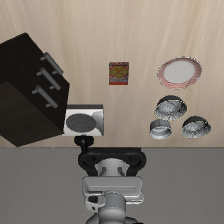

In [15]:
from IPython.display import Image as IPImage
IPImage("/kaggle/working/frame.png")

In [18]:
%%writefile /kaggle/working/test_frames.py
import os, sys
os.environ["MUJOCO_GL"] = "egl"
sys.path.insert(0, "/kaggle/working/openpi/third_party/libero")

import numpy as np
from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv

bench = benchmark.get_benchmark_dict()["libero_spatial"]()
task = bench.get_task(0)
bddl = os.path.join(get_libero_path("bddl_files"), task.problem_folder, task.bddl_file)

env = OffScreenRenderEnv(bddl_file_name=bddl, camera_heights=224, camera_widths=224)
env.seed(0)
obs = env.reset()

bowl = obs["akita_black_bowl_1_pos"]
eef  = obs["robot0_eef_pos"]
rel  = obs["akita_black_bowl_1_to_robot0_eef_pos"]

print("bowl pos      :", bowl)
print("eef pos       :", eef)
print("reported rel  :", rel)
print("bowl - eef    :", bowl - eef)
print("eef - bowl    :", eef - bowl)
print()
print("matches bowl-eef?", np.allclose(rel, bowl - eef, atol=1e-6))
print("matches eef-bowl?", np.allclose(rel, eef - bowl, atol=1e-6))

env.close()

Overwriting /kaggle/working/test_frames.py


In [19]:
!/kaggle/working/openpi/examples/libero/.venv/bin/python /kaggle/working/test_frames.py

[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /kaggle/working/openpi/examples/libero/.venv/lib/python3.8/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[Warning]: datasets path /kaggle/working/openpi/third_party/libero/libero/libero/../datasets does not exist!
/kaggle/working/openpi/examples/libero/.venv/lib/python3.8/site-packages/numba/np/arraymath.py:3845: DeprecationWarning: `np.MachAr` is deprecated (NumPy 1.22).
  @overload(np.MachAr)
bowl pos      : [-0.06390988  0.20349675  0.97      ]
eef pos       : [-0.20846466  0.          1.17327948]
reported rel  : [ 0.1559635  -0.20341997  0.19474417]
bowl - eef    : [ 0.14455478  0.20349675 -0.20327948]
eef - bowl    : [-0.14455478 -0.20349675  0.20327948]

matches bowl-eef? False
matches eef-bowl? False


In [20]:
%%writefile /kaggle/working/test_frames2.py
import os, sys
os.environ["MUJOCO_GL"] = "egl"
sys.path.insert(0, "/kaggle/working/openpi/third_party/libero")

import numpy as np
from scipy.spatial.transform import Rotation as R
from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv

bench = benchmark.get_benchmark_dict()["libero_spatial"]()
task = bench.get_task(0)
bddl = os.path.join(get_libero_path("bddl_files"), task.problem_folder, task.bddl_file)
env = OffScreenRenderEnv(bddl_file_name=bddl, camera_heights=224, camera_widths=224)
env.seed(0); obs = env.reset()

bowl = obs["akita_black_bowl_1_pos"]
eef  = obs["robot0_eef_pos"]
rel  = obs["akita_black_bowl_1_to_robot0_eef_pos"]
quat = obs["robot0_eef_quat"]          # robosuite uses (x, y, z, w)

d = bowl - eef
print("norm(reported) :", np.linalg.norm(rel))
print("norm(bowl-eef) :", np.linalg.norm(d))

Rm = R.from_quat(quat).as_matrix()     # gripper -> world
print("R.T @ (bowl-eef):", Rm.T @ d,   np.allclose(rel, Rm.T @ d, atol=1e-5))
print("R.T @ (eef-bowl):", Rm.T @ -d,  np.allclose(rel, Rm.T @ -d, atol=1e-5))
env.close()

Writing /kaggle/working/test_frames2.py


In [21]:
!/kaggle/working/openpi/examples/libero/.venv/bin/python /kaggle/working/test_frames2.py

[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /kaggle/working/openpi/examples/libero/.venv/lib/python3.8/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[Warning]: datasets path /kaggle/working/openpi/third_party/libero/libero/libero/../datasets does not exist!
/kaggle/working/openpi/examples/libero/.venv/lib/python3.8/site-packages/numba/np/arraymath.py:3845: DeprecationWarning: `np.MachAr` is deprecated (NumPy 1.22).
  @overload(np.MachAr)
norm(reported) : 0.3219154969674648
norm(bowl-eef) : 0.3219154517713768
R.T @ (bowl-eef): [ 0.15596349 -0.20341995  0.19474412] True
R.T @ (eef-bowl): [-0.15596349  0.20341995 -0.19474412] False


In [22]:
%%writefile /kaggle/working/test_flip.py
import os, sys
os.environ["MUJOCO_GL"] = "egl"
sys.path.insert(0, "/kaggle/working/openpi/third_party/libero")
import numpy as np
from PIL import Image
from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv

bench = benchmark.get_benchmark_dict()["libero_spatial"]()
task = bench.get_task(0)
bddl = os.path.join(get_libero_path("bddl_files"), task.problem_folder, task.bddl_file)
env = OffScreenRenderEnv(bddl_file_name=bddl, camera_heights=224, camera_widths=224)
env.seed(0); obs = env.reset()

img = obs["agentview_image"]
Image.fromarray(img[::-1]).save("/kaggle/working/frame_flipped.png")
Image.fromarray(obs["robot0_eye_in_hand_image"][::-1]).save("/kaggle/working/wrist_flipped.png")
print("saved")
env.close()

Writing /kaggle/working/test_flip.py


In [23]:
!/kaggle/working/openpi/examples/libero/.venv/bin/python /kaggle/working/test_flip.py

[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /kaggle/working/openpi/examples/libero/.venv/lib/python3.8/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[Warning]: datasets path /kaggle/working/openpi/third_party/libero/libero/libero/../datasets does not exist!
/kaggle/working/openpi/examples/libero/.venv/lib/python3.8/site-packages/numba/np/arraymath.py:3845: DeprecationWarning: `np.MachAr` is deprecated (NumPy 1.22).
  @overload(np.MachAr)
saved


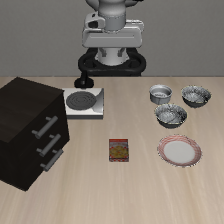

In [24]:
from IPython.display import Image as IPImage
IPImage("/kaggle/working/frame_flipped.png")

In [25]:
!grep -n "image\|flip\|::-1\|rot90" /kaggle/working/openpi/examples/libero/main.py | head -40

7:import imageio
12:from openpi_client import image_tools
101:            replay_images = []
113:                    # Get preprocessed image
115:                    img = np.ascontiguousarray(obs["agentview_image"][::-1, ::-1])
116:                    wrist_img = np.ascontiguousarray(obs["robot0_eye_in_hand_image"][::-1, ::-1])
117:                    img = image_tools.convert_to_uint8(
118:                        image_tools.resize_with_pad(img, args.resize_size, args.resize_size)
120:                    wrist_img = image_tools.convert_to_uint8(
121:                        image_tools.resize_with_pad(wrist_img, args.resize_size, args.resize_size)
124:                    # Save preprocessed image for replay video
125:                    replay_images.append(img)
131:                            "observation/image": img,
132:                            "observation/wrist_image": wrist_img,
170:            imageio.mimwrite(
172:                [np.asarray(x) for x in replay_images],
